In [1]:
import numpy as np

In [2]:
def create_gaussian_kernel(shape, bbox, variance):
    """
    Creates a Gaussian kernel with the specified shape and variance centered on the bbox center,
    only applied within the bbox area, and sets the area outside the bbox to ones.
    :param shape: Tuple (H, W) for the image dimensions.
    :param bbox: Tuple (x, y, w, h) representing the bounding box.
    :param variance: Variance of the Gaussian kernel.
    :return: Gaussian kernel of shape (H, W).
    """
    H, W = shape
    x_center = bbox[0] + bbox[2] // 2
    y_center = bbox[1] + bbox[3] // 2
    x_start, x_end = bbox[0], bbox[0] + bbox[2]
    y_start, y_end = bbox[1], bbox[1] + bbox[3]
    
    # Initialize the kernel with ones
    kernel = np.ones((H, W), dtype=np.float32)
    
    # Create a grid within the bounding box area
    y, x = np.ogrid[y_start:y_end, x_start:x_end]
    
    # Calculate the Gaussian only within the bounding box area
    gaussian = np.exp(-((x - x_center) ** 2 + (y - y_center) ** 2) / (2 * variance))
    inverted_gaussian = 1 - gaussian  # Invert the values

    # Place the inverted Gaussian in the bounding box area of the kernel
    kernel[y_start:y_end, x_start:x_end] = inverted_gaussian

    return kernel

def create_laplacian_kernel(shape, bbox, variance):
    """
    Creates a Laplacian kernel centered on the bbox center,
    applied only within the bbox area, and sets the area outside the bbox to ones.
    :param shape: Tuple (H, W) for the image dimensions.
    :param bbox: Tuple (x, y, w, h) representing the bounding box.
    :param variance: Variance (scale factor) of the Laplacian function.
    :return: Laplacian kernel of shape (H, W).
    """
    H, W = shape
    x_center = bbox[0] + bbox[2] // 2
    y_center = bbox[1] + bbox[3] // 2
    x_start, x_end = bbox[0], bbox[0] + bbox[2]
    y_start, y_end = bbox[1], bbox[1] + bbox[3]

    # Initialize the kernel with ones
    kernel = np.ones((H, W), dtype=np.float32)

    # Create a grid within the bounding box area
    y, x = np.ogrid[y_start:y_end, x_start:x_end]

    # Compute the Laplacian function inside the bbox
    # Mexican Hat (Laplacian of Gaussian, LoG) function
    distance_squared = (x - x_center) ** 2 + (y - y_center) ** 2
    laplacian = (1 - (distance_squared / (2 * variance))) * np.exp(-distance_squared / (2 * variance))

    # Normalize and invert the Laplacian
    inverted_laplacian = 1 - laplacian  # Invert values

    # Place the inverted Laplacian in the bounding box area of the kernel
    kernel[y_start:y_end, x_start:x_end] = inverted_laplacian

    return kernel

def create_epanechnikov_kernel(shape, bbox, radius):
    H, W = shape
    x_center = bbox[0] + bbox[2] // 2
    y_center = bbox[1] + bbox[3] // 2
    x_start, x_end = bbox[0], bbox[0] + bbox[2]
    y_start, y_end = bbox[1], bbox[1] + bbox[3]

    kernel = np.ones((H, W), dtype=np.float32)
    y, x = np.ogrid[y_start:y_end, x_start:x_end]
    distance_squared = (x - x_center) ** 2 + (y - y_center) ** 2
    mask = distance_squared <= radius ** 2
    epanechnikov = np.zeros_like(distance_squared, dtype=np.float32)
    epanechnikov[mask] = 1 - (distance_squared[mask] / radius ** 2)
    inverted = 1 - epanechnikov
    kernel[y_start:y_end, x_start:x_end] = inverted
    return kernel


def create_triangular_kernel(shape, bbox, radius):
    H, W = shape
    x_center = bbox[0] + bbox[2] // 2
    y_center = bbox[1] + bbox[3] // 2
    x_start, x_end = bbox[0], bbox[0] + bbox[2]
    y_start, y_end = bbox[1], bbox[1] + bbox[3]

    kernel = np.ones((H, W), dtype=np.float32)
    y, x = np.ogrid[y_start:y_end, x_start:x_end]
    distance = np.sqrt((x - x_center) ** 2 + (y - y_center) ** 2)
    triangular = np.clip(1 - (distance / radius), 0, 1)
    inverted = 1 - triangular
    kernel[y_start:y_end, x_start:x_end] = inverted
    return kernel

def create_exponential_kernel(shape, bbox, scale):
    H, W = shape
    x_center = bbox[0] + bbox[2] // 2
    y_center = bbox[1] + bbox[3] // 2
    x_start, x_end = bbox[0], bbox[0] + bbox[2]
    y_start, y_end = bbox[1], bbox[1] + bbox[3]

    kernel = np.ones((H, W), dtype=np.float32)
    y, x = np.ogrid[y_start:y_end, x_start:x_end]
    distance = np.sqrt((x - x_center) ** 2 + (y - y_center) ** 2)
    exponential = np.exp(-distance / scale)
    inverted = 1 - exponential
    kernel[y_start:y_end, x_start:x_end] = inverted
    return kernel


def create_cauchy_kernel(shape, bbox, scale):
    H, W = shape
    x_center = bbox[0] + bbox[2] // 2
    y_center = bbox[1] + bbox[3] // 2
    x_start, x_end = bbox[0], bbox[0] + bbox[2]
    y_start, y_end = bbox[1], bbox[1] + bbox[3]

    kernel = np.ones((H, W), dtype=np.float32)
    y, x = np.ogrid[y_start:y_end, x_start:x_end]
    distance_squared = (x - x_center) ** 2 + (y - y_center) ** 2
    cauchy = 1 / (1 + (distance_squared / (scale ** 2)))
    inverted = 1 - cauchy
    kernel[y_start:y_end, x_start:x_end] = inverted
    return kernel


def create_cosine_kernel(shape, bbox, radius):
    H, W = shape
    x_center = bbox[0] + bbox[2] // 2
    y_center = bbox[1] + bbox[3] // 2
    x_start, x_end = bbox[0], bbox[0] + bbox[2]
    y_start, y_end = bbox[1], bbox[1] + bbox[3]

    kernel = np.ones((H, W), dtype=np.float32)
    y, x = np.ogrid[y_start:y_end, x_start:x_end]
    distance = np.sqrt((x - x_center) ** 2 + (y - y_center) ** 2)
    cosine = np.zeros_like(distance)
    mask = distance <= radius
    cosine[mask] = 0.5 * (1 + np.cos(np.pi * distance[mask] / radius))
    inverted = 1 - cosine
    kernel[y_start:y_end, x_start:x_end] = inverted
    return kernel

def create_blur_kernel(shape, bbox):
    """
    Applies a uniform blur (box filter) within the bounding box.
    """
    H, W = shape
    x_start, x_end = bbox[0], bbox[0] + bbox[2]
    y_start, y_end = bbox[1], bbox[1] + bbox[3]

    kernel = np.ones((H, W), dtype=np.float32)
    h, w = y_end - y_start, x_end - x_start

    # Box filter (same value everywhere inside bbox)
    blur_value = 0.5  # You can adjust this
    kernel[y_start:y_end, x_start:x_end] = blur_value
    return kernel

def create_salt_and_pepper_kernel(shape, bbox, amount=0.05):
    """
    Applies salt-and-pepper noise (0 or 1) randomly within the bounding box.
    """
    H, W = shape
    x_start, x_end = bbox[0], bbox[0] + bbox[2]
    y_start, y_end = bbox[1], bbox[1] + bbox[3]
    h, w = y_end - y_start, x_end - x_start

    kernel = np.ones((H, W), dtype=np.float32)

    # Start with a region of ones
    region = np.ones((h, w), dtype=np.float32)

    # Number of pixels to corrupt
    num_pixels = int(amount * h * w)
    coords = np.random.choice(h * w, num_pixels, replace=False)

    # Randomly choose 0 or 1 to apply
    salt_pepper = np.random.choice([0.0, 1.0], size=num_pixels)

    # Flatten, apply noise, and reshape
    flat_region = region.flatten()
    flat_region[coords] = salt_pepper
    region_noised = flat_region.reshape(h, w)

    kernel[y_start:y_end, x_start:x_end] = region_noised
    return kernel



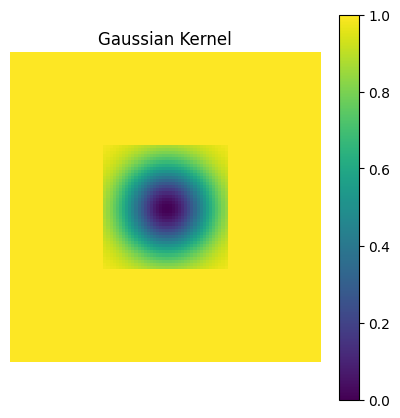

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def show_kernel(kernel, title):
    plt.figure(figsize=(5, 5))
    plt.imshow(kernel, cmap='viridis')
    plt.title(title)
    plt.colorbar()
    plt.axis('off')
    plt.show()

shape = (100, 100)             # Image/kernel shape (height, width)
bbox = (30, 30, 40, 40)        # Bounding box: (x, y, width, height)

variance = 100  # Controls spread
kernel = create_gaussian_kernel(shape, bbox, variance)
show_kernel(kernel, "Gaussian Kernel")



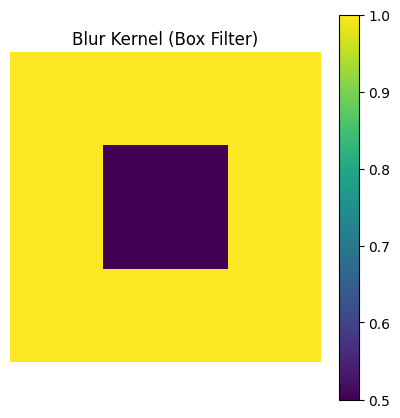

In [4]:
kernel = create_blur_kernel(shape, bbox)
show_kernel(kernel, "Blur Kernel (Box Filter)")

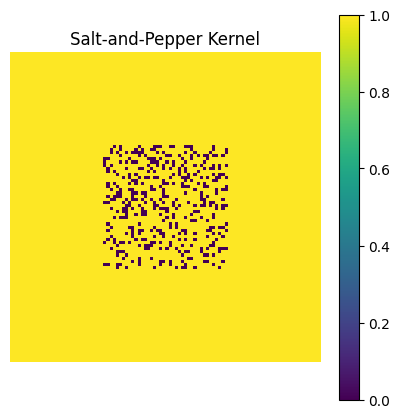

In [5]:
kernel = create_salt_and_pepper_kernel(shape, bbox, amount=0.5)  # 10% noise
show_kernel(kernel, "Salt-and-Pepper Kernel")

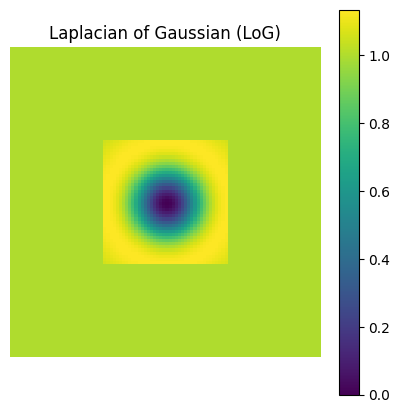

In [6]:
variance = 100
kernel = create_laplacian_kernel(shape, bbox, variance)
show_kernel(kernel, "Laplacian of Gaussian (LoG)")


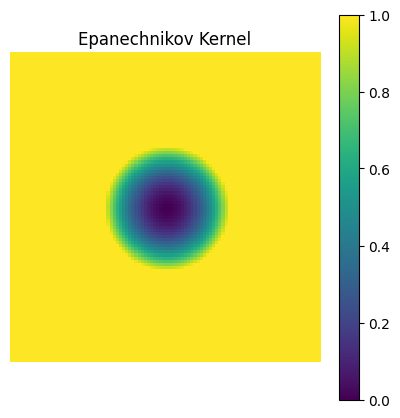

In [7]:
radius = 20
kernel = create_epanechnikov_kernel(shape, bbox, radius)
show_kernel(kernel, "Epanechnikov Kernel")


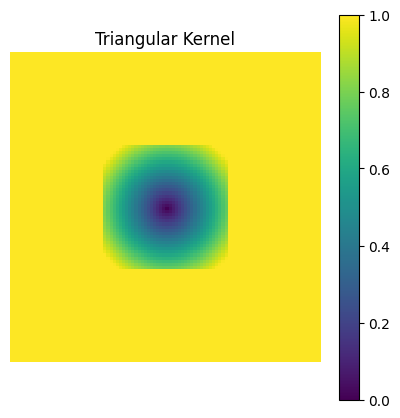

In [8]:
radius = 25
kernel = create_triangular_kernel(shape, bbox, radius)
show_kernel(kernel, "Triangular Kernel")


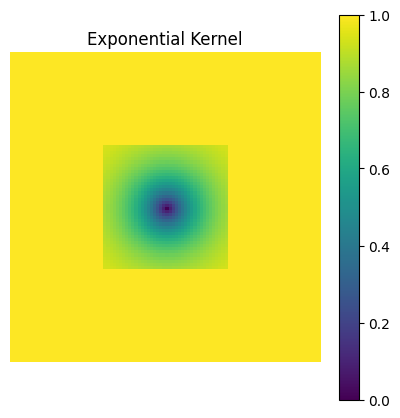

In [9]:
scale = 10
kernel = create_exponential_kernel(shape, bbox, scale)
show_kernel(kernel, "Exponential Kernel")


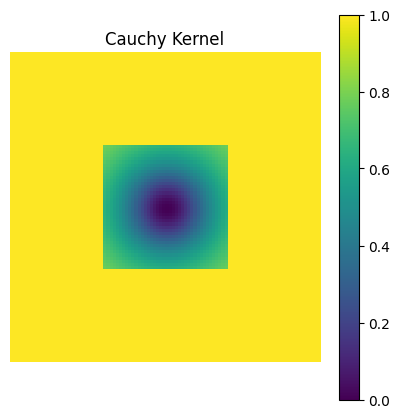

In [10]:
scale = 15
kernel = create_cauchy_kernel(shape, bbox, scale)
show_kernel(kernel, "Cauchy Kernel")


In [35]:
def create_unsharp_masking_kernel(shape, bbox, amount):
    """
    Creates an Unsharp Masking kernel centered on the bbox,
    applied only within the bbox area, and sets the area outside the bbox to ones.
    Unsharp masking enhances edges by subtracting a blurred version of the image.
    :param shape: Tuple (H, W) for the image dimensions.
    :param bbox: Tuple (x, y, w, h) representing the bounding box.
    :param amount: Weight of the sharpening effect.
    :return: Unsharp Masking kernel of shape (H, W).
    """
    H, W = shape
    x_start, x_end = bbox[0], bbox[0] + bbox[2]
    y_start, y_end = bbox[1], bbox[1] + bbox[3]

    # Initialize the kernel with ones
    kernel = np.ones((H, W), dtype=np.float32)

    # Create a basic unsharp mask kernel (sharpening filter)
    # Kernel: (1 + amount) * Identity - amount * Gaussian Blur
    # Using a fixed small Gaussian for simplicity (3x3)
    blur_kernel = np.array([[1, 2, 1],
                            [2, 4, 2],
                            [1, 2, 1]], dtype=np.float32)
    blur_kernel /= blur_kernel.sum()

    # Unsharp kernel is delta kernel minus scaled blur kernel
    unsharp_kernel = (1 + amount) * np.eye(3)[1][np.newaxis, :]  # Center pixel
    unsharp_kernel = np.array([[0, -amount, 0],
                               [-amount, 1 + 4 * amount, -amount],
                               [0, -amount, 0]], dtype=np.float32)

    # Apply the unsharp kernel only within the bbox
    for i in range(y_start + 1, y_end - 1):
        for j in range(x_start + 1, x_end - 1):
            kernel[i-1:i+2, j-1:j+2] = unsharp_kernel

    return kernel


def create_motion_blur_kernel(shape, bbox, length):
    """
    Creates a Motion Blur kernel applied within the bbox area,
    simulating horizontal motion blur. The area outside the bbox is set to ones.
    :param shape: Tuple (H, W) for the image dimensions.
    :param bbox: Tuple (x, y, w, h) representing the bounding box.
    :param length: Length of the motion blur (must be odd).
    :return: Motion Blur kernel of shape (H, W).
    """
    H, W = shape
    x_start, x_end = bbox[0], bbox[0] + bbox[2]
    y_start, y_end = bbox[1], bbox[1] + bbox[3]

    # Initialize the kernel with ones
    kernel = np.ones((H, W), dtype=np.float32)

    # Create a horizontal motion blur kernel of given length
    if length % 2 == 0:
        length += 1  # Ensure odd length

    motion_kernel = np.zeros((1, length), dtype=np.float32)
    motion_kernel[0] = 1.0 / length

    # Apply the motion blur kernel inside the bbox
    for i in range(y_start, y_end):
        for j in range(x_start + length // 2, x_end - length // 2):
            kernel[i, j - length // 2:j + length // 2 + 1] = motion_kernel

    return kernel

def create_fog_kernel(shape, bbox, scale=20.0):
    """
    Creates a fog-like kernel: smooth, gradual increase from the center of the bbox
    to the edges, simulating fog density.
    
    Parameters:
        shape : tuple
            (H, W) size of the kernel/image.
        bbox : list or tuple
            Bounding box [x, y, w, h].
        scale : float
            Controls how fast the fog density decays from the center. Larger = slower decay.
            
    Returns:
        kernel : np.ndarray
            2D kernel of shape (H, W) with fog pattern applied inside bbox.
    """
    H, W = shape
    x_center = bbox[0] + bbox[2] // 2
    y_center = bbox[1] + bbox[3] // 2
    x_start, x_end = bbox[0], bbox[0] + bbox[2]
    y_start, y_end = bbox[1], bbox[1] + bbox[3]

    # Initialize full kernel to 1 (no fog)
    kernel = np.ones((H, W), dtype=np.float32)

    # Coordinate grid within bbox
    y, x = np.ogrid[y_start:y_end, x_start:x_end]
    distance = np.sqrt((x - x_center) ** 2 + (y - y_center) ** 2)

    # Fog effect: smooth exponential decay from center
    fog = 1 - np.exp(-distance / scale)

    # Insert fog into kernel
    kernel[y_start:y_end, x_start:x_end] = fog
    return kernel


def create_binary_gaussian_kernel(shape, bbox, variance, threshold=0.5):
    """
    Creates a binary Gaussian kernel: values >= threshold are 1, others 0.
    """
    H, W = shape
    x_center = bbox[0] + bbox[2] // 2
    y_center = bbox[1] + bbox[3] // 2
    x_start, x_end = bbox[0], bbox[0] + bbox[2]
    y_start, y_end = bbox[1], bbox[1] + bbox[3]

    kernel = np.ones((H, W), dtype=np.float32)
    y, x = np.ogrid[y_start:y_end, x_start:x_end]
    gaussian = np.exp(-((x - x_center) ** 2 + (y - y_center) ** 2) / (2 * variance))
    binary = (gaussian >= threshold).astype(np.float32)

    kernel[y_start:y_end, x_start:x_end] = binary
    return kernel

def create_log_gaussian_kernel(shape, bbox, variance):
    """
    Creates a log-Gaussian kernel: log of Gaussian values normalized to [0, 1].
    """
    H, W = shape
    x_center = bbox[0] + bbox[2] // 2
    y_center = bbox[1] + bbox[3] // 2
    x_start, x_end = bbox[0], bbox[0] + bbox[2]
    y_start, y_end = bbox[1], bbox[1] + bbox[3]

    kernel = np.ones((H, W), dtype=np.float32)
    y, x = np.ogrid[y_start:y_end, x_start:x_end]
    gaussian = np.exp(-((x - x_center) ** 2 + (y - y_center) ** 2) / (2 * variance))
    log_gaussian = np.log(gaussian + 1e-6)  # Avoid log(0)
    normalized = (log_gaussian - log_gaussian.min()) / (log_gaussian.max() - log_gaussian.min())

    kernel[y_start:y_end, x_start:x_end] = normalized
    return kernel


def create_flat_top_gaussian_kernel(shape, bbox, variance, clip_value=0.8):
    """
    Creates a Gaussian kernel with a flat top (values clipped to a max).
    """
    H, W = shape
    x_center = bbox[0] + bbox[2] // 2
    y_center = bbox[1] + bbox[3] // 2
    x_start, x_end = bbox[0], bbox[0] + bbox[2]
    y_start, y_end = bbox[1], bbox[1] + bbox[3]

    kernel = np.ones((H, W), dtype=np.float32)
    y, x = np.ogrid[y_start:y_end, x_start:x_end]
    gaussian = np.exp(-((x - x_center) ** 2 + (y - y_center) ** 2) / (2 * variance))
    flat_top = np.clip(gaussian, clip_value, 1.0)

    kernel[y_start:y_end, x_start:x_end] = flat_top
    return kernel


def create_double_gaussian_kernel(shape, bbox, variance1, variance2, weight=0.5):
    """
    Combines two Gaussians: wide and narrow. Useful for emphasizing central peak with context.
    """
    H, W = shape
    x_center = bbox[0] + bbox[2] // 2
    y_center = bbox[1] + bbox[3] // 2
    x_start, x_end = bbox[0], bbox[0] + bbox[2]
    y_start, y_end = bbox[1], bbox[1] + bbox[3]

    kernel = np.ones((H, W), dtype=np.float32)
    y, x = np.ogrid[y_start:y_end, x_start:x_end]
    gaussian1 = np.exp(-((x - x_center) ** 2 + (y - y_center) ** 2) / (2 * variance1))
    gaussian2 = np.exp(-((x - x_center) ** 2 + (y - y_center) ** 2) / (2 * variance2))
    combined = weight * gaussian1 + (1 - weight) * gaussian2

    kernel[y_start:y_end, x_start:x_end] = combined
    return kernel


def create_gabor_kernel(shape, bbox, variance, frequency=0.2, theta=0):
    """
    Creates a Gabor kernel in the bbox area, ones outside.
    """
    import numpy as np

    H, W = shape
    x_center = bbox[0] + bbox[2] // 2
    y_center = bbox[1] + bbox[3] // 2
    x_start, x_end = bbox[0], bbox[0] + bbox[2]
    y_start, y_end = bbox[1], bbox[1] + bbox[3]

    kernel = np.ones((H, W), dtype=np.float32)
    y, x = np.ogrid[y_start:y_end, x_start:x_end]

    x_shifted = x - x_center
    y_shifted = y - y_center

    # Rotate the coordinates
    x_theta = x_shifted * np.cos(theta) + y_shifted * np.sin(theta)
    y_theta = -x_shifted * np.sin(theta) + y_shifted * np.cos(theta)

    gaussian = np.exp(-(x_theta**2 + y_theta**2) / (2 * variance))
    sinusoid = np.cos(2 * np.pi * frequency * x_theta)

    gabor = gaussian * sinusoid
    kernel[y_start:y_end, x_start:x_end] = gabor

    return kernel


def create_gaussian_polynomial_kernel(shape, bbox, variance, a=1.0, degree=2):
    """
    Gaussian * polynomial kernel applied in bbox, ones elsewhere.
    """
    H, W = shape
    x_center = bbox[0] + bbox[2] // 2
    y_center = bbox[1] + bbox[3] // 2
    x_start, x_end = bbox[0], bbox[0] + bbox[2]
    y_start, y_end = bbox[1], bbox[1] + bbox[3]

    kernel = np.ones((H, W), dtype=np.float32)
    y, x = np.ogrid[y_start:y_end, x_start:x_end]

    dist_sq = (x - x_center) ** 2 + (y - y_center) ** 2
    gaussian = np.exp(-dist_sq / (2 * variance))
    polynomial = (a * dist_sq + 1) ** degree

    combined = gaussian * polynomial
    kernel[y_start:y_end, x_start:x_end] = combined

    return kernel

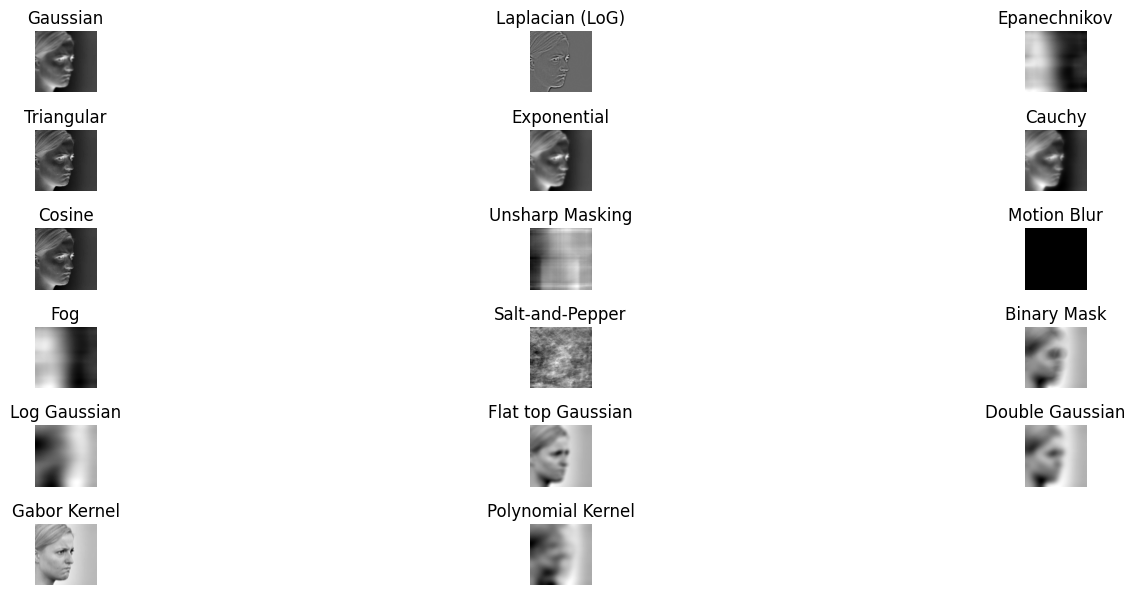

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
import cv2

# Load a grayscale sample image
image = cv2.imread('/home/tico/Documents/DeiDDPG-main/exp/datasets/celeba_hq/celeba/Rafd045_01_Caucasian_female_angry_frontal.jpg', cv2.IMREAD_GRAYSCALE)
image = cv2.resize(image,(128,128))
if image is None:
    raise ValueError("Image not found. Check the path.")

# Normalize image to [0, 1]
image = image.astype(np.float32) / 255.0

# Define image shape and bounding box
shape = image.shape
bbox = (0, 0, shape[1], shape[0])  # (x_min, y_min, x_max, y_max)

kernels = [
    (create_gaussian_kernel(shape, bbox, 1), "Gaussian"),
    (create_laplacian_kernel(shape, bbox, 1), "Laplacian (LoG)"),
    (create_epanechnikov_kernel(shape, bbox, 335), "Epanechnikov"),
    (create_triangular_kernel(shape, bbox, 1), "Triangular"),
    (create_exponential_kernel(shape, bbox, 1), "Exponential"),
    (create_cauchy_kernel(shape, bbox, 1), "Cauchy"),
    (create_cosine_kernel(shape, bbox, 1), "Cosine"),
    (create_unsharp_masking_kernel(shape, bbox, 50), "Unsharp Masking"),
    (create_motion_blur_kernel(shape, bbox, 1), "Motion Blur"),
    (create_fog_kernel(shape, bbox, scale=50), "Fog"),
    (create_salt_and_pepper_kernel(shape, bbox, amount=0.01) , "Salt-and-Pepper"),
    (create_binary_gaussian_kernel(shape, bbox, 100) , "Binary Mask"),
    (create_log_gaussian_kernel(shape, bbox, 50) , "Log Gaussian"),
    (create_flat_top_gaussian_kernel(shape, bbox, 90) , "Flat top Gaussian"),
    (create_double_gaussian_kernel(shape, bbox, 50, 25) , "Double Gaussian"),
    (create_gabor_kernel(shape, bbox, 1) , "Gabor Kernel"),
    (create_gaussian_polynomial_kernel(shape, bbox, 50) , "Polynomial Kernel"),

]

plt.figure(figsize=(15, 10))
for i, (kernel, name) in enumerate(kernels):
    # Normalize kernel for convolution
    kernel = kernel - kernel.mean()
    result = convolve(image, kernel, mode='reflect')

    plt.subplot(10, 3, i + 1)
    plt.imshow(result, cmap='gray')
    plt.title(name)
    plt.axis('off')
plt.tight_layout()
plt.show()
